In [77]:
# pip install pydicom


In [78]:
# Multi_Label_Classification.ipynb

import os
import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
import vision_models.constants as constants
from pydicom.pixel_data_handlers.util import apply_modality_lut
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from keras import layers, models, applications, losses

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


In [79]:
# Set paths
train_images_path = constants.TRAIN_DATA_PATH
train_df = pd.read_csv("NEW_EDA/train_dataset.csv")
val_df = pd.read_csv("NEW_EDA/val_dataset.csv")
test_df = pd.read_csv("NEW_EDA/test_dataset.csv")

# One-hot encode the 'condition' and 'level' columns separately
train_condition_dummies = pd.get_dummies(train_df['condition'], prefix='condition')
train_level_dummies = pd.get_dummies(train_df['level'], prefix='level')

val_condition_dummies = pd.get_dummies(val_df['condition'], prefix='condition')
val_level_dummies = pd.get_dummies(val_df['level'], prefix='level')

test_condition_dummies = pd.get_dummies(test_df['condition'], prefix='condition')
test_level_dummies = pd.get_dummies(test_df['level'], prefix='level')

# Concatenate the dummy columns back to the original DataFrame
train_df = pd.concat([train_df.drop(['condition', 'level'], axis=1), train_condition_dummies, train_level_dummies], axis=1)
val_df = pd.concat([val_df.drop(['condition', 'level'], axis=1), val_condition_dummies, val_level_dummies], axis=1)
test_df = pd.concat([test_df.drop(['condition', 'level'], axis=1), test_condition_dummies, test_level_dummies], axis=1)

# Now you have your DataFrame with one-hot encoded columns for 'condition' and 'level'


In [80]:
train_df = train_df.sample(frac=0.05, random_state=42)
val_df = val_df.sample(frac=0.05, random_state=42)
test_df = test_df.sample(frac=0.05, random_state=42)

train_df

,study_id,series_id,image_name,file_meta_version,sop_class_uid,sop_instance_uid,transfer_syntax_uid,implementation_class_uid,implementation_version_name,content_date,...,condition_Left Neural Foraminal Narrowing,condition_Left Subarticular Stenosis,condition_Right Neural Foraminal Narrowing,condition_Right Subarticular Stenosis,condition_Spinal Canal Stenosis,level_L1/L2,level_L2/L3,level_L3/L4,level_L4/L5,level_L5/S1
29239,1820866003,3689221841,21.dcm,b'\x00\x01',1.2.840.10008.5.1.4.1.1.4.1,1820866003.1.21,1.2.840.10008.1.2.5,1.2.40.0.13.1.1.1,PYDICOM 2.4.2,20240503,...,False,True,False,False,False,False,False,False,False,True
10576,3084269121,1616142642,3.dcm,b'\x00\x01',1.2.840.10008.5.1.4.1.1.4.1,3084269121.1.3,1.2.840.10008.1.2.5,1.2.40.0.13.1.1.1,PYDICOM 2.4.2,20240503,...,False,False,False,False,False,False,False,False,False,False
38534,4173917544,111096887,13.dcm,b'\x00\x01',1.2.840.10008.5.1.4.1.1.4.1,4173917544.1.13,1.2.840.10008.1.2.5,1.2.40.0.13.1.1.1,PYDICOM 2.4.2,20240503,...,False,False,False,False,False,False,False,False,False,False
40490,2905685162,1535449979,14.dcm,b'\x00\x01',1.2.840.10008.5.1.4.1.1.4.1,2905685162.1.14,1.2.840.10008.1.2.5,1.2.40.0.13.1.1.1,PYDICOM 2.4.2,20240503,...,False,False,False,False,False,False,False,False,False,False
115633,861719444,3451308655,87.dcm,b'\x00\x01',1.2.840.10008.5.1.4.1.1.4.1,861719444.1.87,1.2.840.10008.1.2.5,1.2.40.0.13.1.1.1,PYDICOM 2.4.2,20240503,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34244,2492114990,1711913559,37.dcm,b'\x00\x01',1.2.840.10008.5.1.4.1.1.4.1,2492114990.1.37,1.2.840.10008.1.2.5,1.2.40.0.13.1.1.1,PYDICOM 2.4.2,20240503,...,False,False,False,False,False,False,False,False,False,False
28052,2410802623,1323838328,13.dcm,b'\x00\x01',1.2.840.10008.5.1.4.1.1.4.1,2410802623.1.13,1.2.840.10008.1.2.5,1.2.40.0.13.1.1.1,PYDICOM 2.4.2,20240503,...,True,False,False,False,False,False,True,False,False,False
82371,372642770,2853044871,117.dcm,b'\x00\x01',1.2.840.10008.5.1.4.1.1.4.1,372642770.1.117,1.2.840.10008.1.2.5,1.2.40.0.13.1.1.1,PYDICOM 2.4.2,20240503,...,False,False,False,False,False,False,False,False,False,False
21926,2621647501,321494793,5.dcm,b'\x00\x01',1.2.840.10008.5.1.4.1.1.4.1,2621647501.1.5,1.2.840.10008.1.2.5,1.2.40.0.13.1.1.1,PYDICOM 2.4.2,20240503,...,False,False,False,False,False,False,False,False,False,False


In [81]:


# Data Preparation
for df in [train_df, val_df, test_df]:
    df['image_path'] = df.apply(lambda row: os.path.join(train_images_path, str(row['study_id']), str(row['series_id']), f"{row['instance_number']}.dcm"), axis=1)


In [82]:
print(train_df)
print(val_df)
print(test_df)

          study_id   series_id image_name file_meta_version  \
29239   1820866003  3689221841     21.dcm       b'\x00\x01'   
10576   3084269121  1616142642      3.dcm       b'\x00\x01'   
38534   4173917544   111096887     13.dcm       b'\x00\x01'   
40490   2905685162  1535449979     14.dcm       b'\x00\x01'   
115633   861719444  3451308655     87.dcm       b'\x00\x01'   
...            ...         ...        ...               ...   
34244   2492114990  1711913559     37.dcm       b'\x00\x01'   
28052   2410802623  1323838328     13.dcm       b'\x00\x01'   
82371    372642770  2853044871    117.dcm       b'\x00\x01'   
21926   2621647501   321494793      5.dcm       b'\x00\x01'   
43829   2481482581  3901001542      7.dcm       b'\x00\x01'   

                      sop_class_uid sop_instance_uid  transfer_syntax_uid  \
29239   1.2.840.10008.5.1.4.1.1.4.1  1820866003.1.21  1.2.840.10008.1.2.5   
10576   1.2.840.10008.5.1.4.1.1.4.1   3084269121.1.3  1.2.840.10008.1.2.5   
38534   1.2.

In [83]:
# # Function to load and preprocess images using pydicom
# def load_image(img_path, target_size=(224, 224)):
#     img_path = img_path.numpy().decode('utf-8')  # Convert Tensor to string path
#     dicom = pydicom.dcmread(img_path)
#     img = apply_modality_lut(dicom.pixel_array, dicom)
    
#     # Ensure img has 3 dimensions (Height, Width, Channels)
#     if len(img.shape) == 2:  # Grayscale image
#         img = tf.expand_dims(img, axis=-1)  # Add channel dimension
    
#     # Check if the image is still grayscale
#     if img.shape[-1] == 1:
#         # Convert grayscale to RGB (3 channels)
#         img = tf.image.grayscale_to_rgb(img)
    
#     # Convert to float32 immediately
#     img = tf.cast(img, tf.float32)
    
#     # Now resize the image
#     img = tf.image.resize(img, target_size)
    
#     # Normalize pixel values
#     img = img / 255.0
    
#     return img

# Function to read and preprocess images using pydicom
def load_image(img_path, target_size=(224, 224)):
    # Load DICOM file
    dicom = pydicom.dcmread(img_path.numpy().decode('utf-8'))
    img = dicom.pixel_array
    
    # Normalize the image
    img = img / np.max(img)
    
    # Ensure img has 3 dimensions (Height, Width, Channels)
    if len(img.shape) == 2:  # Grayscale image
        img = np.expand_dims(img, axis=-1)  # Add channel dimension
    
    # Convert grayscale to RGB (3 channels) if needed
    if img.shape[-1] == 1:
        img = np.concatenate([img, img, img], axis=-1)
    
    # Convert to float32 immediately
    img = tf.convert_to_tensor(img, dtype=tf.float32)
    
    # Now resize the image
    img = tf.image.resize(img, target_size)
    
    # Normalize pixel values to [0, 1]
    img = img / 255.0
    
    return img

# Wrapper function to use with tf.data.Dataset.map
def load_image_wrapper(img_path, target_size=(224, 224)):
    img = tf.py_function(func=load_image, inp=[img_path], Tout=tf.float32)
    img.set_shape((target_size[0], target_size[1], 3))  # Explicitly set shape (224, 224, 3)
    return img

# Create a TensorFlow dataset
def create_tf_dataset(df, batch_size=32, is_training=True):
    label_columns = [col for col in df.columns if col.startswith('condition_') or col.startswith('level_')]
    dataset = tf.data.Dataset.from_tensor_slices((df['image_path'], df[label_columns]))
    dataset = dataset.map(lambda x, y: (load_image_wrapper(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    
    # Debugging: Print shape of each element in the dataset
    def print_shapes(x, y):
        print(f"Image shape: {x.shape}, Label shape: {y.shape}")
        return x, y
    
    dataset = dataset.map(print_shapes)  # Add this line to print shapes
    
    if is_training:
        dataset = dataset.shuffle(buffer_size=1024)
    dataset = dataset.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset


# Create datasets
train_dataset = create_tf_dataset(train_df)
val_dataset = create_tf_dataset(val_df, is_training=False)
test_dataset = create_tf_dataset(test_df, is_training=False)


Image shape: (224, 224, 3), Label shape: (10,)
Image shape: (224, 224, 3), Label shape: (10,)
Image shape: (224, 224, 3), Label shape: (10,)


In [84]:

# Model 1: Basic CNN Model
model1 = models.Sequential([
    layers.Input(shape=(224, 224, 3)),  # Now expecting 3 channels
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')  # Output for 10 classes
])


model1.compile(optimizer='adam', loss=losses.CategoricalCrossentropy(), metrics=['accuracy'])




In [85]:
# Train the models
history1 = model1.fit(train_dataset, validation_data=val_dataset, epochs=2)


In [66]:

# Model 2: Transfer Learning with ResNet50
base_model = applications.ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model2 = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')  # Output for 10 classes
])

model2.compile(optimizer='adam', loss=losses.CategoricalCrossentropy(), metrics=['accuracy'])



Epoch 1/2


2024-08-13 18:25:06.981341: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:38: Filling up shuffle buffer (this may take a while): 795 of 1024
2024-08-13 18:25:09.825896: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


215/215 ━━━━━━━━━━━━━━━━━━━━ 108s 431ms/step - accuracy: 0.0896 - loss: 252.7248 - val_accuracy: 0.0524 - val_loss: 7618.8105
Epoch 2/2


2024-08-13 18:26:53.990650: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:38: Filling up shuffle buffer (this may take a while): 810 of 1024
2024-08-13 18:26:56.851506: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


215/215 ━━━━━━━━━━━━━━━━━━━━ 104s 425ms/step - accuracy: 0.0868 - loss: 14324.1445 - val_accuracy: 0.0631 - val_loss: 57516.2461


In [67]:
history2 = model2.fit(train_dataset, validation_data=val_dataset, epochs=2)

Epoch 1/2


2024-08-13 18:28:45.359097: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:38: Filling up shuffle buffer (this may take a while): 820 of 1024
2024-08-13 18:28:47.751495: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


215/215 ━━━━━━━━━━━━━━━━━━━━ 128s 496ms/step - accuracy: 0.0956 - loss: 1.3626 - val_accuracy: 0.0000e+00 - val_loss: 1.7195
Epoch 2/2


2024-08-13 18:30:46.709321: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:38: Filling up shuffle buffer (this may take a while): 797 of 1024
2024-08-13 18:30:49.567334: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


215/215 ━━━━━━━━━━━━━━━━━━━━ 114s 470ms/step - accuracy: 0.1057 - loss: 1.5695 - val_accuracy: 0.0000e+00 - val_loss: 1.6409


Accuracy: [0.09760724008083344, 0.09702363610267639]
Val Accuracy: [0.05238095298409462, 0.06309524178504944]


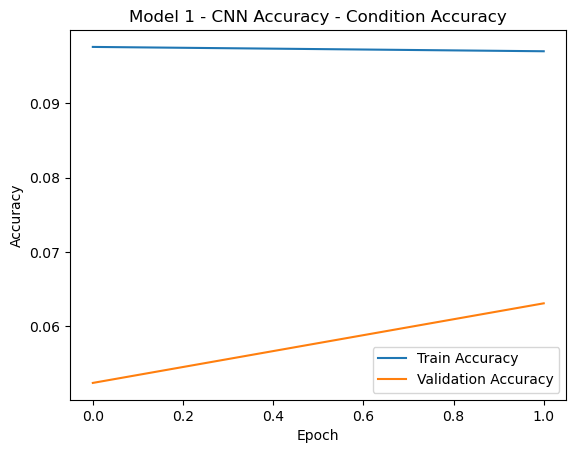

Accuracy: [0.09994164109230042, 0.13087248802185059]
Val Accuracy: [0.0, 0.0]


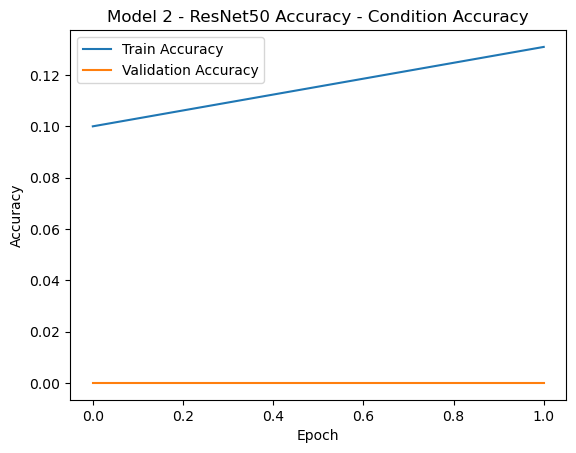

Label classes being used: ['condition_Left Neural Foraminal Narrowing', 'condition_Left Subarticular Stenosis', 'condition_Right Neural Foraminal Narrowing', 'condition_Right Subarticular Stenosis', 'condition_Spinal Canal Stenosis', '(blank)']
Label columns used: ['condition_Left Neural Foraminal Narrowing', 'condition_Left Subarticular Stenosis', 'condition_Right Neural Foraminal Narrowing', 'condition_Right Subarticular Stenosis', 'condition_Spinal Canal Stenosis']
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 356ms/step
Predictions shape: (840, 10)
Predicted labels:
[6 4 6 6 4 4 6 2 6 4 5 4 4 6 4 4 4 4 6 4 4 4 1 4 6 4 4 4 4 4 4 4 4 6 6 4 6
 4 4 4 4 4 4 4 4 4 1 5 4 6 4 4 4 4 6 4 4 4 4 5 4 4 4 4 4 4 4 6 4 4 4 4 6 6
 6 4 4 6 6 4 4 4 4 4 4 4 4 4 4 4 4 4 6 4 4 4 4 4 4 4 4 4 4 4 4 4 6 4 4 4 4
 4 4 4 5 4 4 4 6 6 6 5 4 6 6 6 4 4 4 4 4 4 6 4 4 4 4 2 4 4 4 4 4 7 4 4 4 1
 4 4 4 6 4 4 4 4 4 4 6 1 4 4 4 4 4 4 6 4 4 4 4 4 4 4 4 6 4 5 4 4 4 4 4 4 4
 4 6 4 4 4 4 4 4 1 4 4 4 4 0 6 6 4 6 6 4 4 4 4 5 4 4 4 6 4 4 4 

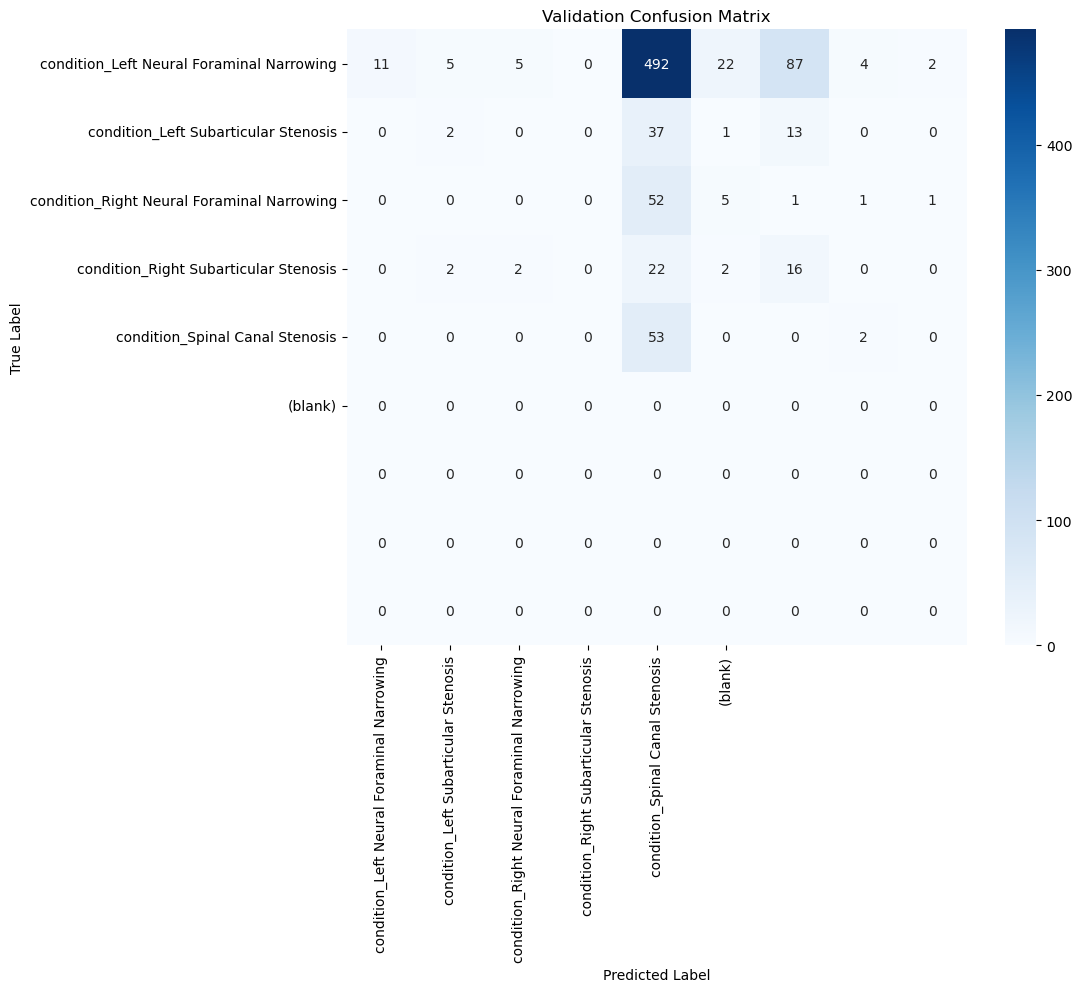

Saved predictions to NEW_EDA/Validation_predictions.csv
Label columns used: ['condition_Left Neural Foraminal Narrowing', 'condition_Left Subarticular Stenosis', 'condition_Right Neural Foraminal Narrowing', 'condition_Right Subarticular Stenosis', 'condition_Spinal Canal Stenosis']
17/28 ━━━━━━━━━━━━━━━━━━━━ 4s 377ms/step

KeyboardInterrupt: 

In [86]:
# predicting condition

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# Plot training history
def plot_metrics(history, title):
    print('Condition Accuracy:', history.history['accuracy'])
    print('Condition Val Accuracy:',history.history['val_accuracy'])
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.savefig(f'NEW_EDA/{title}.png')
    plt.show()

# Example usage of plot_metrics
plot_metrics(history1, "Model 1 - CNN Accuracy - Condition")
plot_metrics(history2, "Model 2 - ResNet50 Accuracy - Condition")

# Plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, yticklabels=classes)
    
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

def save_predictions_to_csv(true_labels, predicted_labels, df, dataset_name, label_classes):
    # Ensure all predicted labels are within the valid range
    predicted_labels = np.clip(predicted_labels, 0, len(label_classes) - 1)
    
    # Map the indices back to their actual label names
    true_names = [label_classes[i] for i in true_labels]
    predicted_names = [label_classes[i] for i in predicted_labels]
    
    # Create a DataFrame with true and predicted labels
    results_df = pd.DataFrame({
        'image_path': df['image_path'],
        'true_label': true_names,
        'predicted_label': predicted_names
    })
    
    # Save the DataFrame to CSV
    results_df.to_csv(f'NEW_EDA/{dataset_name}_predictions.csv', index=False)
    print(f"Saved predictions to NEW_EDA/{dataset_name}_predictions.csv")


# Evaluate the model and plot the confusion matrix
def evaluate_model(model, dataset, df, dataset_name, label_classes):
    # Get all columns that start with 'condition_' only
    label_columns = [col for col in df.columns if col.startswith('condition_')]
    print("Label columns used:", label_columns)
    
    # Make predictions
    predictions = model.predict(dataset)
    print("Predictions shape:", predictions.shape)
    
    # Convert predictions and true labels to class indices
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(df[label_columns].values, axis=1)
    
    print(f"Predicted labels:\n{predicted_labels}")
    print(f"True labels:\n{true_labels}")
    
    # Check the unique classes in both true and predicted labels
    unique_true_labels = set(true_labels)
    unique_pred_labels = set(predicted_labels)
    
    print(f"Unique true labels: {unique_true_labels}")
    print(f"Unique predicted labels: {unique_pred_labels}")
    
    print(f"Evaluation on {dataset_name} Data:")
    try:
        print(classification_report(true_labels, predicted_labels, target_names=label_classes))
    except ValueError as e:
        print(f"Error during classification report generation: {e}")
        print(f"True labels: {true_labels}")
        print(f"Predicted labels: {predicted_labels}")
        print(f"Label classes: {label_classes}")
    
    # Plot confusion matrix
    plot_confusion_matrix(true_labels, predicted_labels, classes=label_classes, title=f'{dataset_name} Confusion Matrix')
    
    # Save predictions and actual labels to CSV
    save_predictions_to_csv(true_labels, predicted_labels, df, dataset_name, label_classes)

# Example usage with actual condition labels
label_classes = [col for col in val_df.columns if col.startswith('condition_')]  # Use the original condition column names

# Add an 'blank' label if necessary
if '(blank)' not in label_classes:
    label_classes.append('(blank)')

print("Label classes being used:", label_classes)

# Evaluate on Validation and Test datasets with pretty confusion matrix and save to CSV
evaluate_model(model1, val_dataset, val_df, "Validation", label_classes)
evaluate_model(model1, test_dataset, test_df, "Test", label_classes)

evaluate_model(model2, val_dataset, val_df, "Validation", label_classes)
evaluate_model(model2, test_dataset, test_df, "Test", label_classes)

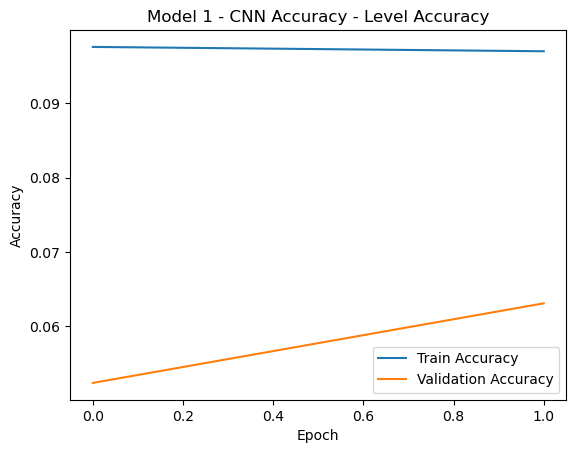

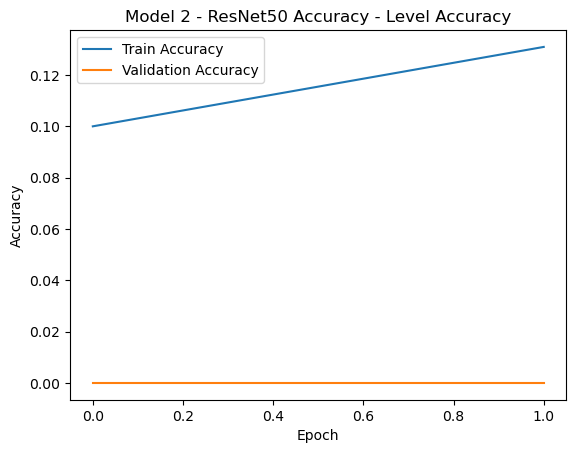

Label classes being used: ['level_L1/L2', 'level_L2/L3', 'level_L3/L4', 'level_L4/L5', 'level_L5/S1', '(blank)']
Label columns used: ['level_L1/L2', 'level_L2/L3', 'level_L3/L4', 'level_L4/L5', 'level_L5/S1']
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 363ms/step
Predictions shape: (840, 10)
Predicted labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 

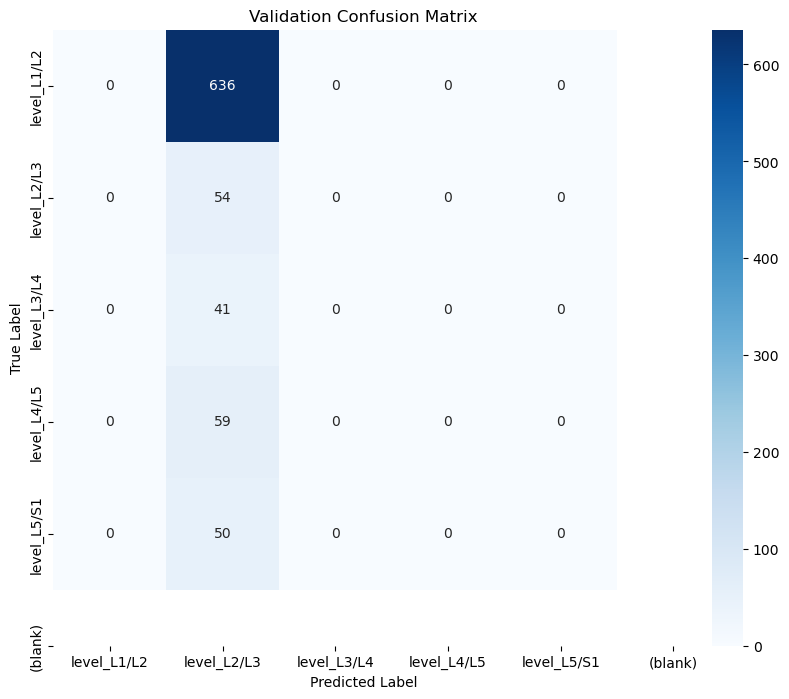

Validation_level_predictions.csv saved successfully!
Label columns used: ['level_L1/L2', 'level_L2/L3', 'level_L3/L4', 'level_L4/L5', 'level_L5/S1']
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 364ms/step
Predictions shape: (870, 10)
Predicted labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1

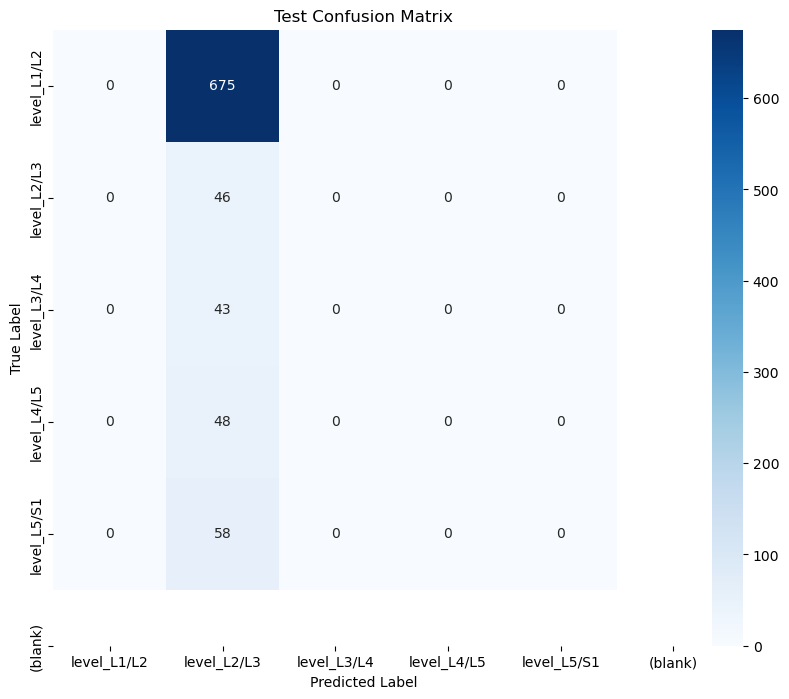

Test_level_predictions.csv saved successfully!
Label columns used: ['level_L1/L2', 'level_L2/L3', 'level_L3/L4', 'level_L4/L5', 'level_L5/S1']
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 428ms/step
Predictions shape: (840, 10)
Predicted labels:
[6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6

/opt/conda/envs/vision/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/envs/vision/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/envs/vision/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/envs/visio

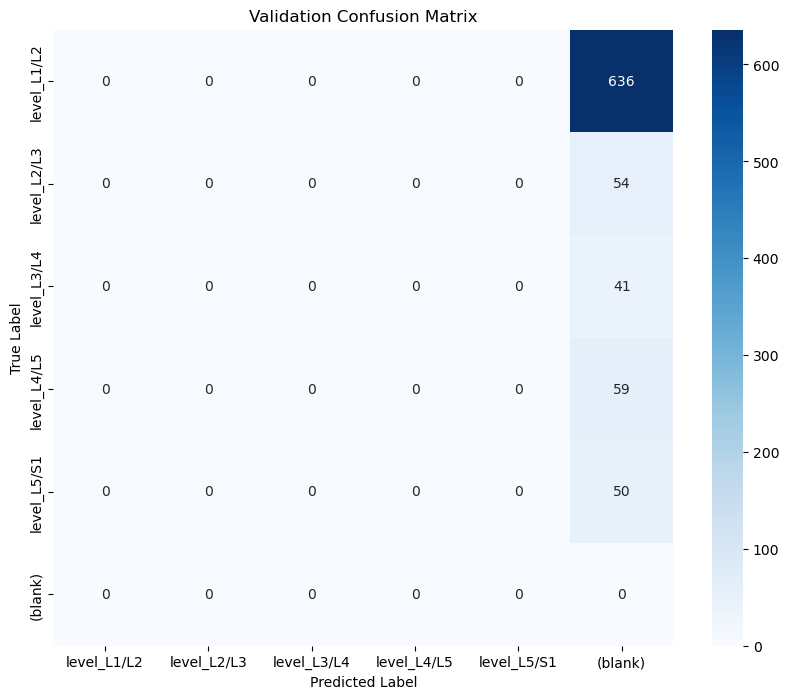

Validation_level_predictions.csv saved successfully!
Label columns used: ['level_L1/L2', 'level_L2/L3', 'level_L3/L4', 'level_L4/L5', 'level_L5/S1']
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 429ms/step
Predictions shape: (870, 10)
Predicted labels:
[6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6

/opt/conda/envs/vision/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/envs/vision/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/envs/vision/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/envs/visio

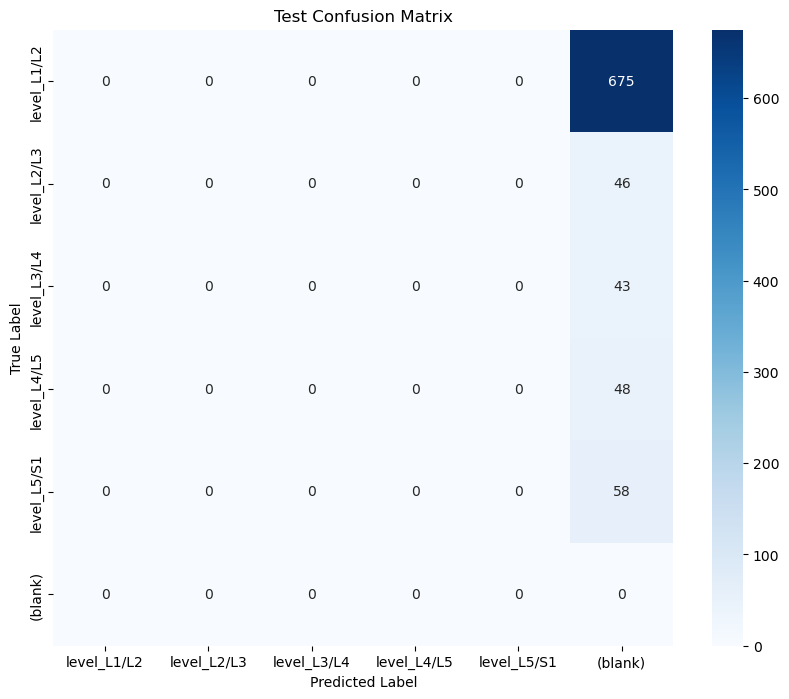

Test_level_predictions.csv saved successfully!


In [72]:
# predicting LEVEL

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# Plot training history
def plot_metrics(history, title):
    print('Level Accuracy:', history.history['accuracy'])
    print('Level Val Accuracy:',history.history['val_accuracy'])
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.savefig(f'NEW_EDA/{title}.png')
    plt.show()

# Example usage of plot_metrics
plot_metrics(history1, "Model 1 - CNN Accuracy - Level")
plot_metrics(history2, "Model 2 - ResNet50 Accuracy - Level")

# Plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, yticklabels=classes)
    
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Function to save predictions and actual labels to CSV
def save_predictions_to_csv(true_labels, predicted_labels, df, dataset_name, label_classes):
    # Ensure all predicted labels are within the valid range
    predicted_labels = np.clip(predicted_labels, 0, len(label_classes) - 1)
    
    # Map the indices back to their actual label names
    true_names = [label_classes[i] for i in true_labels]
    predicted_names = [label_classes[i] for i in predicted_labels]
    
    # Create a DataFrame with true and predicted labels
    results_df = pd.DataFrame({
        'image_path': df['image_path'],
        'true_label': true_names,
        'predicted_label': predicted_names
    })
    
    # Save to CSV
    results_df.to_csv(f'NEW_EDA/{dataset_name}_level_predictions.csv', index=False)
    print(f"{dataset_name}_level_predictions.csv saved successfully!")

# Evaluate the model and plot the confusion matrix
def evaluate_model(model, dataset, df, dataset_name, label_classes):
    # Get all columns that start with 'level_' only
    label_columns = [col for col in df.columns if col.startswith('level_')]
    print("Label columns used:", label_columns)
    
    # Make predictions
    predictions = model.predict(dataset)
    print("Predictions shape:", predictions.shape)
    
    # Convert predictions and true labels to class indices
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(df[label_columns].values, axis=1)
    
    print(f"Predicted labels:\n{predicted_labels}")
    print(f"True labels:\n{true_labels}")
    
    # Check the unique classes in both true and predicted labels
    unique_true_labels = set(true_labels)
    unique_pred_labels = set(predicted_labels)
    
    print(f"Unique true labels: {unique_true_labels}")
    print(f"Unique predicted labels: {unique_pred_labels}")
    
    print(f"Evaluation on {dataset_name} Data:")
    try:
        print(classification_report(true_labels, predicted_labels, target_names=label_classes))
    except ValueError as e:
        print(f"Error during classification report generation: {e}")
        print(f"True labels: {true_labels}")
        print(f"Predicted labels: {predicted_labels}")
        print(f"Label classes: {label_classes}")
    
    # Plot confusion matrix
    plot_confusion_matrix(true_labels, predicted_labels, classes=label_classes, title=f'{dataset_name} Confusion Matrix')
    
    # Save predictions and actual labels to CSV
    save_predictions_to_csv(true_labels, predicted_labels, df, dataset_name, label_classes)

# Example usage with actual level labels
label_classes = [col for col in val_df.columns if col.startswith('level_')]  # Use the original level column names

# Add a 'blank' label if necessary
if '(blank)' not in label_classes:
    label_classes.append('(blank)')

print("Label classes being used:", label_classes)

# Evaluate on Validation and Test datasets with pretty confusion matrix and save to CSV
evaluate_model(model1, val_dataset, val_df, "Validation", label_classes)
evaluate_model(model1, test_dataset, test_df, "Test", label_classes)

evaluate_model(model2, val_dataset, val_df, "Validation", label_classes)
evaluate_model(model2, test_dataset, test_df, "Test", label_classes)


# To predict both condition and level simultaneously, you can treat this as a multi-output model problem. Here’s how you can modify your code to predict both:


In [73]:
# Create a TensorFlow dataset with multi-output
def create_tf_dataset(df, batch_size=32, is_training=True):
    condition_columns = [col for col in df.columns if col.startswith('condition_')]
    level_columns = [col for col in df.columns if col.startswith('level_')]

    # Construct the dataset with dictionary labels
    dataset = tf.data.Dataset.from_tensor_slices((df['image_path'], 
                                                  {'condition_output': df[condition_columns], 
                                                   'level_output': df[level_columns]}))
    
    dataset = dataset.map(lambda x, y: (load_image_wrapper(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    
    if is_training:
        dataset = dataset.shuffle(buffer_size=1024)
    dataset = dataset.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return dataset

# Create datasets
train_dataset = create_tf_dataset(train_df)
val_dataset = create_tf_dataset(val_df, is_training=False)
test_dataset = create_tf_dataset(test_df, is_training=False)


In [74]:
from keras import layers, models

# Determine the number of classes for condition and level
num_condition_classes = len([col for col in df.columns if col.startswith('condition_')])
num_level_classes = len([col for col in df.columns if col.startswith('level_')])


# Model 1: Basic CNN Model with two outputs
input_layer = layers.Input(shape=(224, 224, 3))
x = layers.Conv2D(32, (3, 3), activation='relu')(input_layer)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)

# Two outputs
condition_output = layers.Dense(num_condition_classes, activation='softmax', name='condition_output')(x)
level_output = layers.Dense(num_level_classes, activation='softmax', name='level_output')(x)

# Define the model
model3 = models.Model(inputs=input_layer, outputs=[condition_output, level_output])

model3.compile(optimizer='adam', 
              loss={'condition_output': 'categorical_crossentropy', 'level_output': 'categorical_crossentropy'}, 
              metrics={'condition_output': 'accuracy', 'level_output': 'accuracy'})


# Train the model
history3 = model3.fit(train_dataset, validation_data=val_dataset, epochs=2)



Epoch 1/2


2024-08-13 18:40:27.084127: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:56: Filling up shuffle buffer (this may take a while): 812 of 1024
2024-08-13 18:40:29.681395: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


215/215 ━━━━━━━━━━━━━━━━━━━━ 106s 421ms/step - condition_output_accuracy: 0.2119 - level_output_accuracy: 0.2036 - loss: 473.0711 - val_condition_output_accuracy: 0.0524 - val_level_output_accuracy: 0.7571 - val_loss: 14784.2051
Epoch 2/2


2024-08-13 18:42:11.331190: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:56: Filling up shuffle buffer (this may take a while): 856 of 1024
2024-08-13 18:42:13.301697: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


215/215 ━━━━━━━━━━━━━━━━━━━━ 103s 423ms/step - condition_output_accuracy: 0.1994 - level_output_accuracy: 0.2212 - loss: 33048.8125 - val_condition_output_accuracy: 0.0714 - val_level_output_accuracy: 0.0702 - val_loss: 144265.3750


In [75]:
# Model 2: ResNet50

# Define the input shape
input_shape = (224, 224, 3)

# Load the ResNet50 base model with pre-trained weights, exclude the top layers
base_model = applications.ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)
base_model.trainable = False  # Freeze the base model

# Add custom layers on top of ResNet50 base
inputs = layers.Input(shape=input_shape)
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)

# Two outputs
condition_output = layers.Dense(num_condition_classes, activation='softmax', name='condition_output')(x)
level_output = layers.Dense(num_level_classes, activation='softmax', name='level_output')(x)

# Define the model
model4 = models.Model(inputs=inputs, outputs=[condition_output, level_output])

# Compile the model with multiple losses and metrics for each output
model4.compile(
    optimizer='adam',
    loss={'condition_output': 'categorical_crossentropy', 'level_output': 'categorical_crossentropy'},
    metrics={'condition_output': 'accuracy', 'level_output': 'accuracy'}
)

# Train the model
history4 = model4.fit(train_dataset, validation_data=val_dataset, epochs=2)

Epoch 1/2


2024-08-13 18:44:12.314275: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:56: Filling up shuffle buffer (this may take a while): 831 of 1024
2024-08-13 18:44:14.729484: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


215/215 ━━━━━━━━━━━━━━━━━━━━ 132s 512ms/step - condition_output_accuracy: 0.0642 - level_output_accuracy: 0.5569 - loss: 0.9847 - val_condition_output_accuracy: 0.7476 - val_level_output_accuracy: 0.0643 - val_loss: 1.0458
Epoch 2/2


2024-08-13 18:46:17.224800: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:56: Filling up shuffle buffer (this may take a while): 810 of 1024
2024-08-13 18:46:19.934555: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


215/215 ━━━━━━━━━━━━━━━━━━━━ 115s 477ms/step - condition_output_accuracy: 0.2697 - level_output_accuracy: 0.3981 - loss: 0.9993 - val_condition_output_accuracy: 0.0714 - val_level_output_accuracy: 0.0488 - val_loss: 1.0251


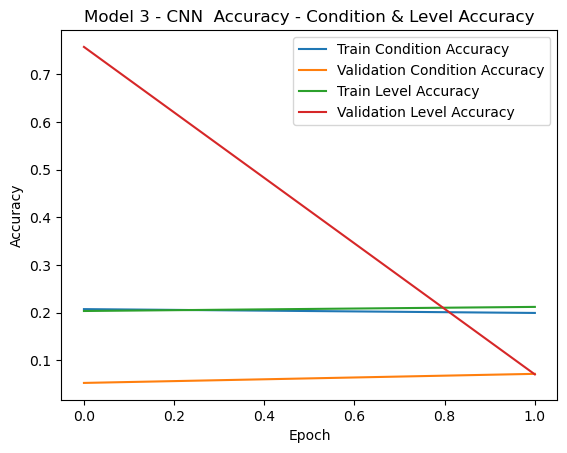

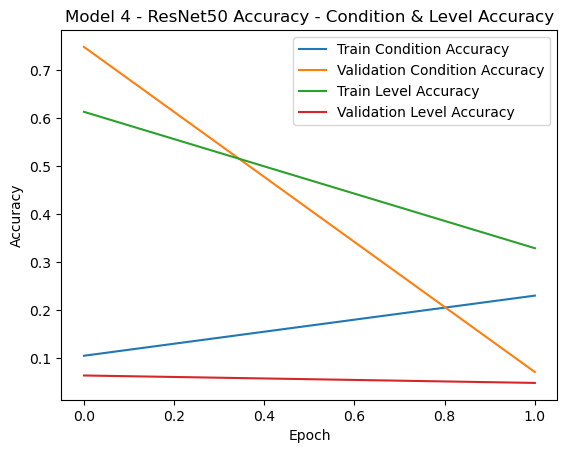

Condition classes being used: ['condition_Left Neural Foraminal Narrowing', 'condition_Left Subarticular Stenosis', 'condition_Right Neural Foraminal Narrowing', 'condition_Right Subarticular Stenosis', 'condition_Spinal Canal Stenosis', '(blank)']
Level classes being used: ['level_L1/L2', 'level_L2/L3', 'level_L3/L4', 'level_L4/L5', 'level_L5/S1', '(blank)']
Condition columns used: ['condition_Left Neural Foraminal Narrowing', 'condition_Left Subarticular Stenosis', 'condition_Right Neural Foraminal Narrowing', 'condition_Right Subarticular Stenosis', 'condition_Spinal Canal Stenosis']
Level columns used: ['level_L1/L2', 'level_L2/L3', 'level_L3/L4', 'level_L4/L5', 'level_L5/S1']
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 390ms/step
Condition Predictions shape: (840, 5)
Level Predictions shape: (840, 5)
Predicted Condition labels:
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2

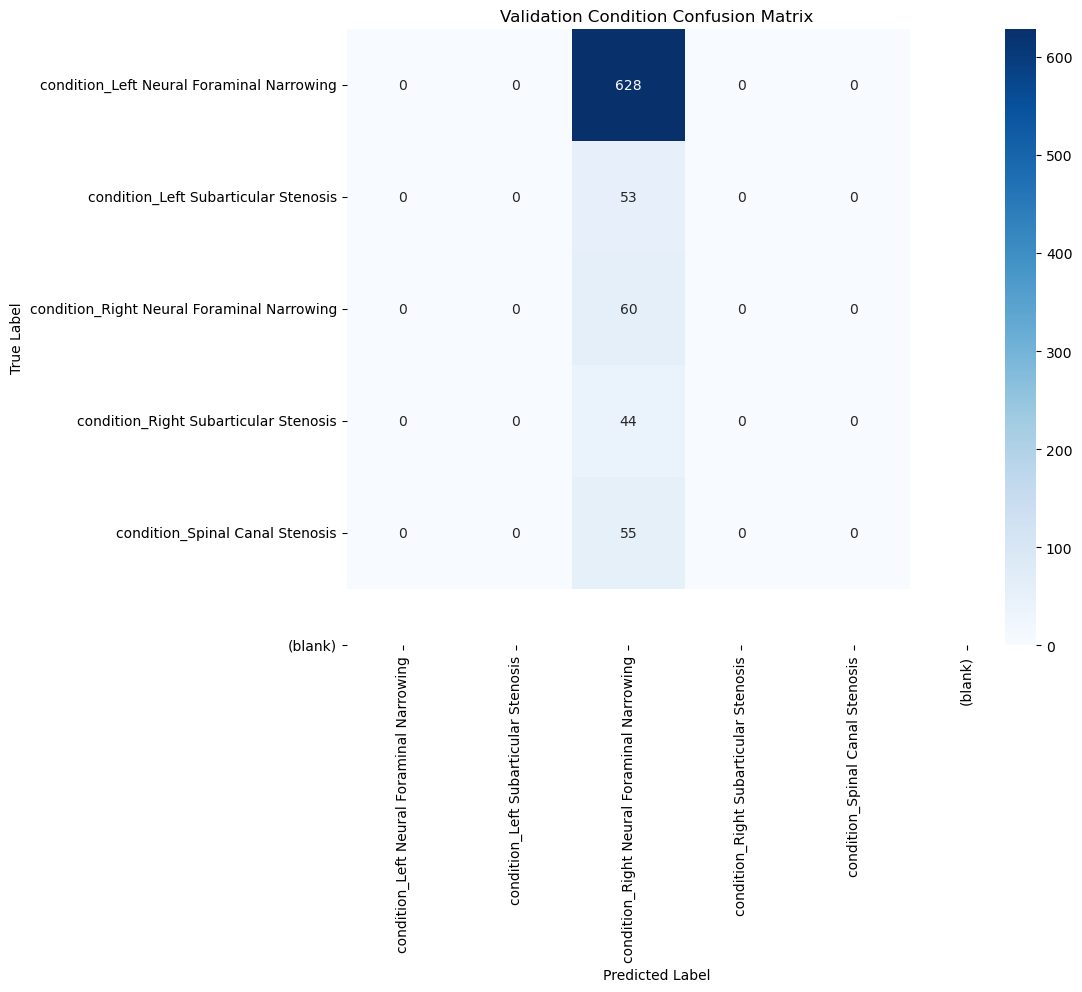

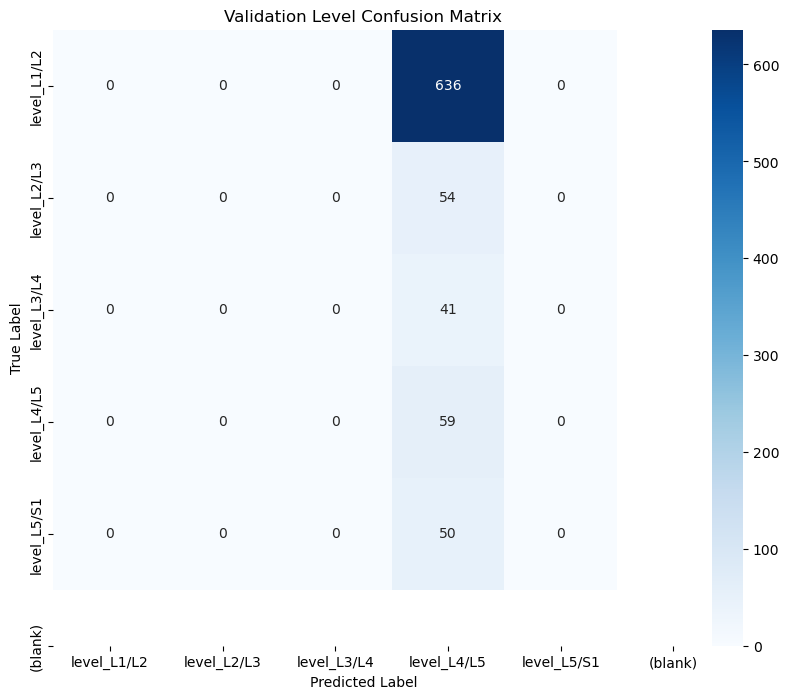

Validation_con_level_predictions.csv saved successfully!
Condition columns used: ['condition_Left Neural Foraminal Narrowing', 'condition_Left Subarticular Stenosis', 'condition_Right Neural Foraminal Narrowing', 'condition_Right Subarticular Stenosis', 'condition_Spinal Canal Stenosis']
Level columns used: ['level_L1/L2', 'level_L2/L3', 'level_L3/L4', 'level_L4/L5', 'level_L5/S1']
28/28 ━━━━━━━━━━━━━━━━━━━━ 19s 513ms/step
Condition Predictions shape: (870, 5)
Level Predictions shape: (870, 5)
Predicted Condition labels:
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 

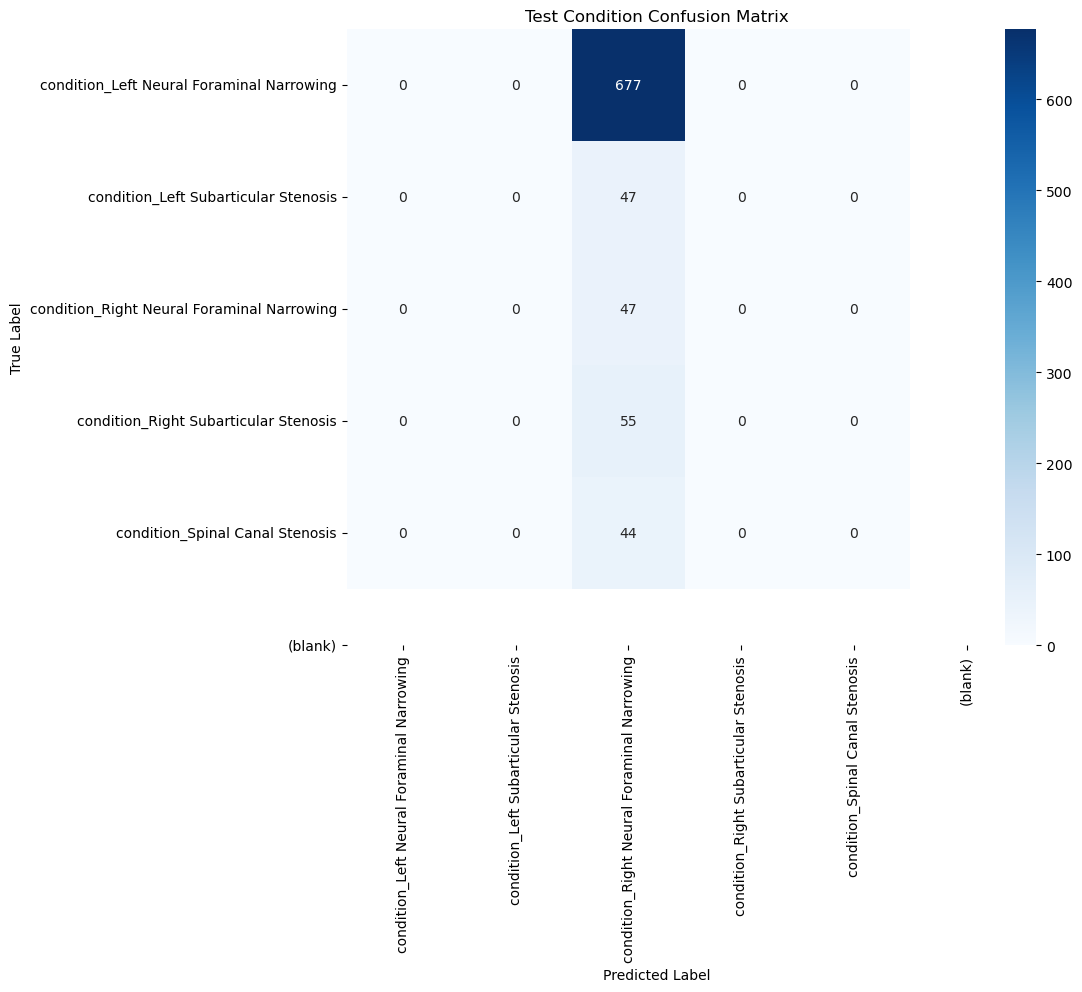

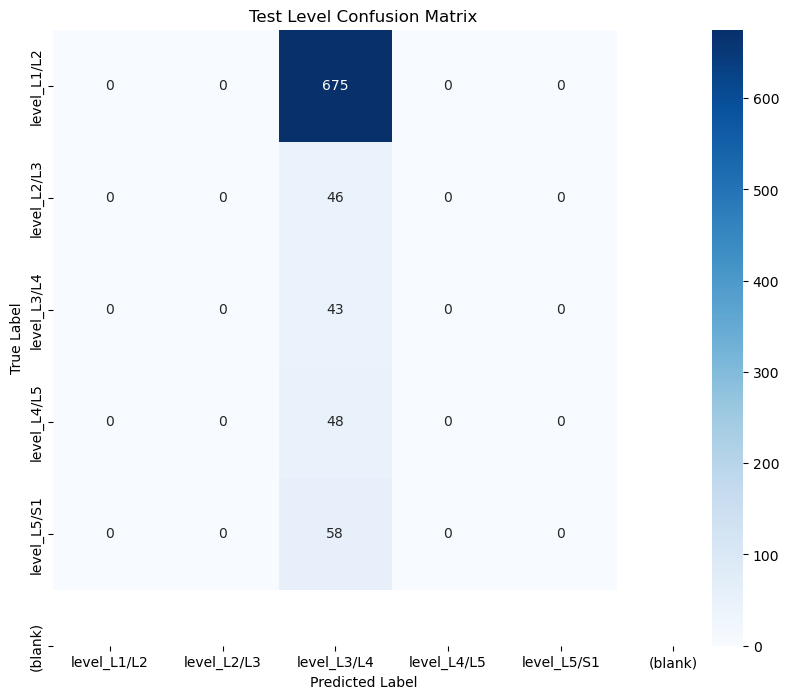

Test_con_level_predictions.csv saved successfully!


In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Function to save predictions and actual labels to CSV
def save_predictions_to_csv(condition_true_labels, condition_predicted_labels, level_true_labels, level_predicted_labels, df, dataset_name):
    # Map the indices back to their actual label names
    condition_true_names = [condition_classes[i] for i in condition_true_labels]
    condition_predicted_names = [condition_classes[i] for i in condition_predicted_labels]
    level_true_names = [level_classes[i] for i in level_true_labels]
    level_predicted_names = [level_classes[i] for i in level_predicted_labels]
    
    # Create a DataFrame with true and predicted labels
    results_df = pd.DataFrame({
        'image_path': df['image_path'],
        'condition_true': condition_true_names,
        'condition_predicted': condition_predicted_names,
        'level_true': level_true_names,
        'level_predicted': level_predicted_names
    })
    
    # Save to CSV
    results_df.to_csv(f'NEW_EDA/{dataset_name}_con_level_predictions.csv', index=False)
    print(f"{dataset_name}_con_level_predictions.csv saved successfully!")


# Plot training history
def plot_metrics(history, title):
    plt.plot(history.history['condition_output_accuracy'], label='Train Condition Accuracy')
    plt.plot(history.history['val_condition_output_accuracy'], label='Validation Condition Accuracy')
    plt.plot(history.history['level_output_accuracy'], label='Train Level Accuracy')
    plt.plot(history.history['val_level_output_accuracy'], label='Validation Level Accuracy')
    plt.title(f'{title} Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.savefig(f'NEW_EDA/{title}.png')
    plt.show()

# Example usage of plot_metrics
plot_metrics(history3, "Model 3 - CNN  Accuracy - Condition & Level")
plot_metrics(history4, "Model 4 - ResNet50 Accuracy - Condition & Level")

# Plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, yticklabels=classes)
    
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Evaluate the model and plot the confusion matrices for both condition and level
def evaluate_model(model, dataset, df, dataset_name, condition_classes, level_classes):
    # Get all columns that start with 'condition_' and 'level_'
    condition_columns = [col for col in df.columns if col.startswith('condition_')]
    level_columns = [col for col in df.columns if col.startswith('level_')]
    
    print("Condition columns used:", condition_columns)
    print("Level columns used:", level_columns)
    
    # Make predictions
    predictions = model.predict(dataset)
    print("Condition Predictions shape:", predictions[0].shape)
    print("Level Predictions shape:", predictions[1].shape)
    
    # Convert predictions and true labels to class indices
    condition_predicted_labels = np.argmax(predictions[0], axis=1)
    level_predicted_labels = np.argmax(predictions[1], axis=1)
    condition_true_labels = np.argmax(df[condition_columns].values, axis=1)
    level_true_labels = np.argmax(df[level_columns].values, axis=1)
    
    print(f"Predicted Condition labels:\n{condition_predicted_labels}")
    print(f"True Condition labels:\n{condition_true_labels}")
    print(f"Predicted Level labels:\n{level_predicted_labels}")
    print(f"True Level labels:\n{level_true_labels}")
    
    # Check the unique classes in both true and predicted labels
    unique_condition_true_labels = set(condition_true_labels)
    unique_condition_pred_labels = set(condition_predicted_labels)
    unique_level_true_labels = set(level_true_labels)
    unique_level_pred_labels = set(level_predicted_labels)
    
    print(f"Unique true condition labels: {unique_condition_true_labels}")
    print(f"Unique predicted condition labels: {unique_condition_pred_labels}")
    print(f"Unique true level labels: {unique_level_true_labels}")
    print(f"Unique predicted level labels: {unique_level_pred_labels}")
    
    print(f"Evaluation on {dataset_name} Data (Condition):")
    try:
        print(classification_report(condition_true_labels, condition_predicted_labels, target_names=condition_classes))
    except ValueError as e:
        print(f"Error during classification report generation: {e}")
        print(f"Condition True labels: {condition_true_labels}")
        print(f"Condition Predicted labels: {condition_predicted_labels}")
        print(f"Condition classes: {condition_classes}")
    
    print(f"Evaluation on {dataset_name} Data (Level):")
    try:
        print(classification_report(level_true_labels, level_predicted_labels, target_names=level_classes))
    except ValueError as e:
        print(f"Error during classification report generation: {e}")
        print(f"Level True labels: {level_true_labels}")
        print(f"Level Predicted labels: {level_predicted_labels}")
        print(f"Level classes: {level_classes}")
    
    # Plot confusion matrices
    plot_confusion_matrix(condition_true_labels, condition_predicted_labels, classes=condition_classes, title=f'{dataset_name} Condition Confusion Matrix')
    plot_confusion_matrix(level_true_labels, level_predicted_labels, classes=level_classes, title=f'{dataset_name} Level Confusion Matrix')

    # Save predictions and actual labels to CSV
    save_predictions_to_csv(condition_true_labels, condition_predicted_labels, level_true_labels, level_predicted_labels, df, dataset_name)


# Example usage with actual labels
condition_classes = [col for col in val_df.columns if col.startswith('condition_')]  # Use the original condition column names
level_classes = [col for col in val_df.columns if col.startswith('level_')]  # Use the original level column names

# Add a '(blank)' label if necessary
if '(blank)' not in condition_classes:
    condition_classes.append('(blank)')
if '(blank)' not in level_classes:
    level_classes.append('(blank)')

print("Condition classes being used:", condition_classes)
print("Level classes being used:", level_classes)

# Evaluate on Validation and Test datasets with pretty confusion matrix
evaluate_model(model3, val_dataset, val_df, "Validation", condition_classes, level_classes)
evaluate_model(model4, test_dataset, test_df, "Test", condition_classes, level_classes)
